In [3]:
from matplotlib import image
from matplotlib import pyplot
# load image as pixel array
image = image.imread('dog.jpg')

uint8
(520, 780, 3)


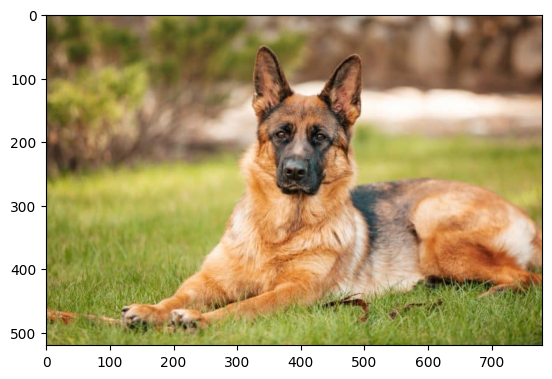

In [4]:
print(image.dtype)
print(image.shape)
# display the array of pixels as an image
pyplot.imshow(image)
pyplot.show()

Padded Img array shape :  (522, 782, 3)


100%|███████████████████████████████████████████████████████████████████████████████| 520/520 [00:02<00:00, 188.81it/s]


(520, 780)


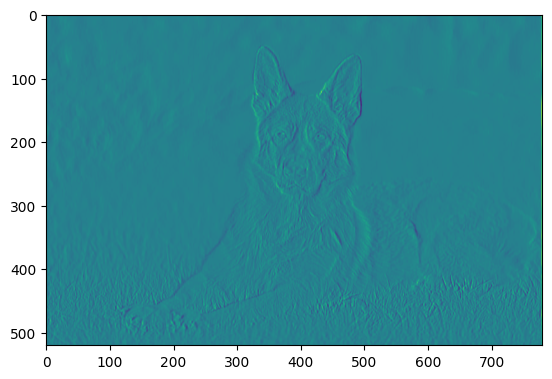

In [5]:


from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math



img_array = mpimg.imread('dog.jpg')

fltr_len = 3

# vertical sobel filter
_filter = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# horizontal sobel filter
_filter = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

kernel = np.repeat(_filter[None, :], 3, axis=0)
transposed_kernel = np.transpose(kernel)


# print(kernel, kernel.shape)
# print(transposed_kernel, transposed_kernel.shape)

result = np.zeros(img_array.shape[:2])

image_array = np.pad(img_array, ((1,1), (1,1), (0,0)))

img_row_len, img_col_len, img_depth_len = image_array.shape

print("Padded Img array shape : ", image_array.shape)

for i in tqdm(range(img_row_len - fltr_len + 1)):
    for j in range(img_col_len - fltr_len + 1):
        img_slice = image_array[i:i+fltr_len, j:j+fltr_len]
        # print(i, i+ fltr_len, j, j+ fltr_len)
        # print(img_slice)
        # print(img_slice.shape)
        result[i,j] = np.sum(np.multiply(img_slice, transposed_kernel))
        
#         print("Img Slice Shape : ", img_slice.shape)
#         print("Img Slice : ", img_slice)
#         print(matrix.shape)
#         print(matrix)
#         # result[i, j] = np.sum(np.multiply(img_array[i:i+fltr_len, j:j+fltr_len], _filter))
#         print("++++++++++++++++++++++++")
#     print("*******************************************")
print(result.shape)

plt.imshow(result)
plt.show()

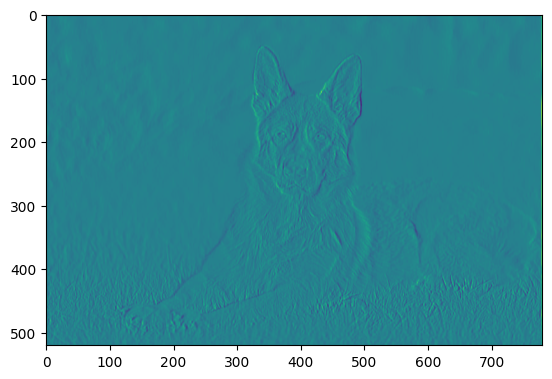

In [7]:
plt.imshow(result)
plt.show()

In [8]:
import mnist

In [9]:
train_images = mnist.train_images()[:1000]
train_labels = mnist.train_labels()[:1000]
test_images = mnist.test_images()[:1000]
test_labels = mnist.test_labels()[:1000]

In [11]:
train_images.shape

(1000, 28, 28)

In [12]:
img1 = train_images[1]

In [13]:
img1.shape

(28, 28)

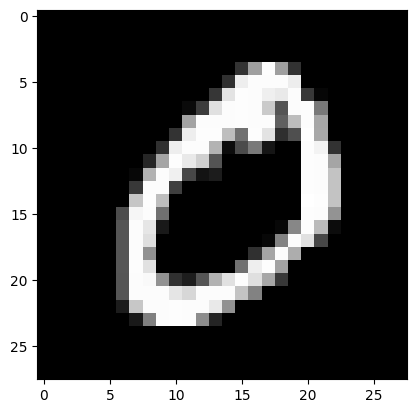

In [14]:
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)  

In [15]:
img1.shape

(28, 28)

In [16]:
def conv2d(img_array, _filter, padding, stride):

    img_row_len, img_col_len = img_array.shape
    fltr_len = _filter.shape[0] # filter is a square matrix as row len == col len
    
    output_row_size = ((img_row_len - fltr_len + 2*padding)/stride) + 1  # if decimal then invalid padding / filter / stride
    output_col_size = ((img_col_len - fltr_len + 2*padding)/stride) + 1
    
    if (output_row_size != int(output_row_size)) or (output_col_size != int(output_col_size)):
        raise Exception("row and col size should be an integers not float")
        
    output_row_size = int(output_row_size)
    output_col_size = int(output_col_size)

    result = np.zeros((output_row_size, output_col_size))

    for i in tqdm(range(img_row_len - fltr_len + 1)):
        for j in range(img_col_len - fltr_len + 1):
            result[i, j] = np.sum(np.multiply(img_array[i:i+fltr_len, j:j+fltr_len], _filter))
    return result

100%|████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 5908.75it/s]

(28, 28)


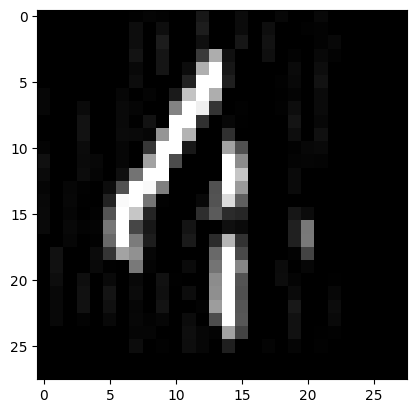

In [19]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math


# def rgb2gray(rgb):
#     return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

img = mpimg.imread('four.jpg')

filter_sharpen = np.array([
    [-1, 1, 0],
    [-1, 1, 0],
    [-1, 1, 0]
])

padding = 1

stride = 1

output_img_array = conv2d(img, filter_sharpen, padding, stride)
print(output_img_array.shape)
plt.imshow(output_img_array, cmap='gray', vmin=0, vmax=255)

100%|████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 4410.95it/s]

(28, 28)


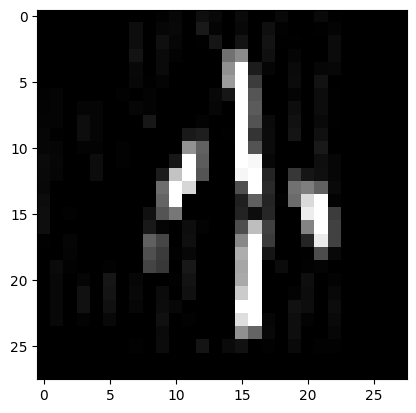

In [20]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math


# def rgb2gray(rgb):
#     return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

img = mpimg.imread('four.jpg')

filter_sharpen = np.array([
    [0, 1, -1],
    [0, 1, -1],
    [0, 1, -1]
])

padding = 1

stride = 1

output_img_array = conv2d(img, filter_sharpen, padding, stride)
print(output_img_array.shape)
plt.imshow(output_img_array, cmap='gray', vmin=0, vmax=255)